# Notebook Guide: Taglish Grammar Correction

This notebook trains and evaluates a Taglish grammar correction model that fixes phrasing while preserving meaning, slang, and code-switching.

## At a Glance
- Purpose: correct Taglish sentences without translating them
- Model: Mistral-7B-Instruct v0.2 fine-tuned with LoRA
- Data: Hugging Face dataset mggy/taglish-socialmedia-dataset, filtered and modified into labeled noisy/clean Taglish pairs
- Evaluation: ROUGE, exact-match checks, confusion-matrix analysis, and speed benchmarks
- Output: trained model, plots, and prediction files for reuse

## Runtime
- CUDA auto-detection is enabled in the first setup cell
- Training hardware used: NVIDIA RTX A5000 with 25.43 GB GPU memory
- The notebook uses fp16 and CUDA memory optimizations when a GPU is available

## Saved Outputs
- Model: change this!
- Figures: model_evaluation.png and confusion_matrix.png
- Exports: predictions.json, predictions.csv, and corrections_report.txt

The notebook is meant to keep Taglish style intact while improving grammar and readability.

In [3]:
# Setup and Dependencies
import pandas as pd
import numpy as np
import os
import json
import re
import unicodedata
from typing import Dict, List, Tuple, Optional
from pathlib import Path
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# ML/NLP
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import (
    AutoTokenizer, 
    AutoModelForSeq2SeqLM,
    AutoModelForCausalLM,
    Trainer, 
    TrainingArguments,
    DataCollatorForSeq2Seq,
)
from peft import get_peft_model, LoraConfig, TaskType
from datasets import Dataset as HFDataset

# Metrics
from rouge import Rouge
import nltk
from nltk.translate.gleu_score import sentence_gleu

# Check GPU availability
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")
if device == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

# Set seed for reproducibility
np.random.seed(42)
torch.manual_seed(42)
if device == "cuda":
    torch.cuda.manual_seed(42)

Device: cuda
GPU: NVIDIA RTX A5000
GPU Memory: 25.43 GB


## Step 1: Setup & Dependencies
Import all required libraries for data processing, model training, and evaluation.

In [4]:
# 1. Load and Explore Dataset (from CSV)
from pathlib import Path

# Use the provided dataset file
dataset_path = Path("/home/johncarlonas/FINAL_PROJECT/dataset/dataset_final (1).csv")
assert dataset_path.exists(), f"Dataset not found: {dataset_path}"

# Read CSV safely
# keep_default_na=False preserves literal strings like 'N/A' if present in text
# then we normalize empty strings manually below.
df = pd.read_csv(dataset_path, encoding="utf-8", keep_default_na=False)

# Normalize key columns used downstream
for col in ["noisy_text", "clean_text", "language_type", "sentiment", "density_range"]:
    if col in df.columns:
        df[col] = df[col].astype(str).str.strip()
        df.loc[df[col] == "", col] = np.nan

# Normalize boolean label column if present
if "labeled" in df.columns:
    if df["labeled"].dtype == object:
        df["labeled"] = df["labeled"].astype(str).str.strip().str.upper().map({
            "TRUE": True,
            "FALSE": False,
            "1": True,
            "0": False,
        }).fillna(False)
    else:
        df["labeled"] = df["labeled"].astype(bool)
else:
    # If labels are not provided, assume rows are trainable pairs
    df["labeled"] = True

# Ensure an ID exists for traceability
if "id" not in df.columns:
    df["id"] = np.arange(1, len(df) + 1)

print(f"Dataset path: {dataset_path}")
print(f"Dataset shape: {df.shape}")
print(f"\nColumn names:\n{df.columns.tolist()}")
print(f"\n--- Dataset Info ---")
print(df.info())
print(f"\n--- First 3 rows ---")
print(df.head(3)[["id", "noisy_text", "clean_text", "language_type", "labeled"]].to_string())
print(f"\n--- Data Quality Check ---")
print(f"Missing values:\n{df.isnull().sum()}")
print(f"\nData types:\n{df.dtypes}"
)

Dataset path: /home/johncarlonas/FINAL_PROJECT/dataset/dataset_final (1).csv
Dataset shape: (7707, 11)

Column names:
['id', 'noisy_text', 'source', 'language_type', 'code_switch_density', 'density_range', 'emoji_count', 'has_emoji', 'sentiment', 'labeled', 'clean_text']

--- Dataset Info ---
<class 'pandas.DataFrame'>
RangeIndex: 7707 entries, 0 to 7706
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   7707 non-null   int64  
 1   noisy_text           7707 non-null   str    
 2   source               7707 non-null   str    
 3   language_type        7707 non-null   str    
 4   code_switch_density  7707 non-null   float64
 5   density_range        7707 non-null   str    
 6   emoji_count          7707 non-null   int64  
 7   has_emoji            7707 non-null   bool   
 8   sentiment            7707 non-null   str    
 9   labeled              7707 non-null   bool   
 10  clean

## Step 2: Load & Explore Dataset
Read the CSV file and inspect data quality, columns, and basic statistics.

In [5]:
# 2. Define TaglishTextNormalizer + dataset filtering
import re

class TaglishTextNormalizer:
    """Normalize Taglish text while preserving meaning and style."""

    def fix_encoding_artifacts(self, text: str) -> str:
        if not isinstance(text, str):
            return text

        text = text.replace("\u2018", "'").replace("\u2019", "'")
        text = text.replace("\u201c", '"').replace("\u201d", '"')
        text = text.replace("\u2013", "-").replace("\u2014", "--")
        return text

    def normalize_punctuation(self, text: str) -> str:
        if not isinstance(text, str):
            return text

        text = re.sub(r"\s{2,}", " ", text)
        text = re.sub(r"\s+([,.!?;:])", r"\1", text)
        text = re.sub(r"\.{4,}", "...", text)
        return text

    def clean_text(self, text: str) -> str:
        if not isinstance(text, str) or len(text.strip()) == 0:
            return text

        text = text.strip()
        text = self.fix_encoding_artifacts(text)
        text = self.normalize_punctuation(text)
        return text

normalizer = TaglishTextNormalizer()

# Keep labeled Taglish rows with valid noisy/clean pairs
train_df = df.copy()
train_df = train_df[train_df["labeled"] == True]
train_df = train_df[train_df["language_type"].str.lower() == "taglish"]
train_df = train_df.dropna(subset=["noisy_text", "clean_text"]).copy()

# Remove exact duplicates and overly short pairs that add training noise
train_df["noisy_text"] = train_df["noisy_text"].astype(str).apply(normalizer.clean_text)
train_df["clean_text"] = train_df["clean_text"].astype(str).apply(normalizer.clean_text)
train_df = train_df[(train_df["noisy_text"].str.len() >= 3) & (train_df["clean_text"].str.len() >= 3)]
train_df = train_df.drop_duplicates(subset=["noisy_text", "clean_text"]).copy()

# Keep examples that actually require correction more often.
# This improves signal-to-noise for grammar transformation training.
changed_mask = train_df["noisy_text"].str.lower() != train_df["clean_text"].str.lower()
changed_df = train_df[changed_mask]
unchanged_df = train_df[~changed_mask]

# Retain a small slice of unchanged pairs so the model still learns "do not over-correct" behavior.
unchanged_keep = unchanged_df.sample(frac=0.20, random_state=42) if len(unchanged_df) > 0 else unchanged_df
train_df = pd.concat([changed_df, unchanged_keep], ignore_index=True)
train_df = train_df.sample(frac=1.0, random_state=42).reset_index(drop=True)

print(f"\n=== DATASET FILTERING ===")
print(f"Total examples: {len(df)}")
print(f"Labeled examples: {len(df[df['labeled'] == True])}")
print(f"Taglish + labeled + valid pairs: {len(changed_df) + len(unchanged_df)}")
print(f"Changed pairs kept: {len(changed_df)}")
print(f"Unchanged pairs kept (20%): {len(unchanged_keep)}")
print(f"Final trainable rows: {len(train_df)}")

if "sentiment" in train_df.columns:
    print(f"\nSentiment distribution:\n{train_df['sentiment'].value_counts(dropna=False)}")
if "code_switch_density" in train_df.columns:
    print(
        f"\nCode-switch density range: "
        f"{train_df['code_switch_density'].min():.2f} - {train_df['code_switch_density'].max():.2f}"
    )

print(f"\n=== NORMALIZATION TEST ===")
for idx, row in train_df[["noisy_text", "clean_text"]].head(3).iterrows():
    print(f"\nExample {idx + 1}:")
    print(f"  Noisy : {row['noisy_text'][:100]}")
    print(f"  Clean : {row['clean_text'][:100]}")


=== DATASET FILTERING ===
Total examples: 7707
Labeled examples: 7707
Taglish + labeled + valid pairs: 4392
Changed pairs kept: 4211
Unchanged pairs kept (20%): 36
Final trainable rows: 4247

Sentiment distribution:
sentiment
positive    1562
neutral     1468
negative    1217
Name: count, dtype: int64

Code-switch density range: 0.20 - 0.88

=== NORMALIZATION TEST ===

Example 1:
  Noisy : Pano po kung 1 month na since nagkakilala kami tapos pinakilala niya ako sa mama niya, does it apply
  Clean : Paano po kung isang buwan na simula nang nagkakilala kami tapos pinakilala niya ako sa mama niya, do

Example 2:
  Noisy : Look up d'angello russel ice in my veins sa yt
  Clean : Look up D'Angelo Russell "ice in my veins" sa YT.

Example 3:
  Noisy : DONT TELL ME ANOTHER 4 YEARS NANAMAN YUNG NEXT????
  Clean : Dont tell me another 4 years na naman yung next.


## Step 3: Preprocess & Filter Data
Normalize text, remove duplicates, filter to Taglish entries, and separate changed/unchanged pairs.

In [6]:
# 3. Data Preparation: Split + instruction formatting
from sklearn.model_selection import train_test_split
from typing import Tuple

# Use a robust stratification key when available
if "density_range" in train_df.columns and train_df["density_range"].notna().all():
    stratify_key = train_df["density_range"]
elif "sentiment" in train_df.columns and train_df["sentiment"].notna().all():
    stratify_key = train_df["sentiment"]
else:
    stratify_key = None

# 80/10/10 split
train_data, temp_data = train_test_split(
    train_df,
    test_size=0.2,
    random_state=42,
    stratify=stratify_key,
)

if stratify_key is not None:
    temp_stratify = temp_data[stratify_key.name] if stratify_key.name in temp_data.columns else None
else:
    temp_stratify = None

val_data, test_data = train_test_split(
    temp_data,
    test_size=0.5,
    random_state=42,
    stratify=temp_stratify,
)

print(f"Train split: {len(train_data)} ({len(train_data)/len(train_df)*100:.1f}%)")
print(f"Val split: {len(val_data)} ({len(val_data)/len(train_df)*100:.1f}%)")
print(f"Test split: {len(test_data)} ({len(test_data)/len(train_df)*100:.1f}%)")

def create_instruction_prompt(noisy_text: str) -> Tuple[str, str]:
    """Create compact instruction format for Taglish correction."""
    system_prompt = (
        "You are a Taglish grammar corrector. Preserve meaning, tone, slang, and code-switching. "
        "Only fix grammar, punctuation, spacing, and obvious spelling errors. "
        "Return only the corrected sentence."
    )
    user_prompt = f"Correct this Taglish sentence:\n{noisy_text}"
    return system_prompt, user_prompt

def build_examples(data_slice: pd.DataFrame):
    examples = []
    for _, row in data_slice.iterrows():
        system, user = create_instruction_prompt(row["noisy_text"])
        examples.append({
            "system": system,
            "input": user,
            "output": str(row["clean_text"]),
            "id": int(row["id"]),
        })
    return examples

train_examples = build_examples(train_data)
val_examples = build_examples(val_data)
test_examples = build_examples(test_data)

print(f"\nTrain examples: {len(train_examples)}")
print(f"Val examples: {len(val_examples)}")
print(f"Test examples: {len(test_examples)}")

print(f"\n--- Instruction Format Example ---")
print(f"System:\n  {train_examples[0]['system'][:180]}...")
print(f"\nInput:\n  {train_examples[0]['input'][:180]}...")
print(f"\nOutput:\n  {train_examples[0]['output'][:180]}...")

Train split: 3397 (80.0%)
Val split: 425 (10.0%)
Test split: 425 (10.0%)

Train examples: 3397
Val examples: 425
Test examples: 425

--- Instruction Format Example ---
System:
  You are a Taglish grammar corrector. Preserve meaning, tone, slang, and code-switching. Only fix grammar, punctuation, spacing, and obvious spelling errors. Return only the correct...

Input:
  Correct this Taglish sentence:
Tama pastor true faith at true accept Jesus by also always prayer for.our salvation ng lumayas proudly pastors....

Output:
  Tama, Pastor. True faith and true accept Jesus by also always prayer for our salvation na lumayas proudly pastors....


## Step 4: Data Splitting & Instruction Format
Split data into train/val/test (80/10/10) and format as instruction-tuning examples.

In [7]:
# 4. Model Selection and LoRA Configuration
from peft import LoraConfig, TaskType, get_peft_model
from transformers import AutoTokenizer, AutoModelForCausalLM, AutoModelForSeq2SeqLM

MODEL_CHOICE = "mistral"  # Options: "mistral", "flan-t5", "mt5"

if MODEL_CHOICE == "mistral":
    MODEL_NAME = "mistralai/Mistral-7B-Instruct-v0.2"
    MODEL_TYPE = "decoder-only"
    IS_SEQ2SEQ = False
elif MODEL_CHOICE == "flan-t5":
    MODEL_NAME = "google/flan-t5-base"
    MODEL_TYPE = "seq2seq"
    IS_SEQ2SEQ = True
else:
    MODEL_NAME = "mistralai/Mistral-7B-Instruct-v0.2"
    IS_SEQ2SEQ = False

print(f"\n=== Model Selection ===")
print(f"Model: {MODEL_NAME}")
print(f"Type: {MODEL_TYPE}")
print(f"Seq2Seq: {IS_SEQ2SEQ}")
print(f"\nRationale:")
print(f"- Mistral-7B-Instruct: Strong instruction-following, good multilingual support")
print(f"- Suitable for code-switched text and conversational correction")
print(f"- LoRA fine-tuning keeps parameters efficient (~5-10M trainable vs 7B total)")

# LoRA Configuration
lora_config = LoraConfig(
    r=8,
    lora_alpha=16,
    target_modules=["q_proj", "v_proj"],
    lora_dropout=0.05,
    bias="none",
    task_type=TaskType.CAUSAL_LM if not IS_SEQ2SEQ else TaskType.SEQ_2_SEQ_LM,
)

print(f"\n--- LoRA Configuration ---")
print(f"Rank (r): {lora_config.r}")
print(f"Alpha: {lora_config.lora_alpha}")
print(f"Target modules: {lora_config.target_modules}")
print(f"Dropout: {lora_config.lora_dropout}")


=== Model Selection ===
Model: mistralai/Mistral-7B-Instruct-v0.2
Type: decoder-only
Seq2Seq: False

Rationale:
- Mistral-7B-Instruct: Strong instruction-following, good multilingual support
- Suitable for code-switched text and conversational correction
- LoRA fine-tuning keeps parameters efficient (~5-10M trainable vs 7B total)

--- LoRA Configuration ---
Rank (r): 8
Alpha: 16
Target modules: {'v_proj', 'q_proj'}
Dropout: 0.05


## Step 5: Model Selection & LoRA Configuration
Choose Mistral-7B-Instruct and configure LoRA for efficient fine-tuning.

In [8]:
# 5. Load Model, Tokenizer, and Prepare HF Datasets
import torch
from datasets import Dataset as HFDataset
from transformers import DataCollatorForSeq2Seq
from rouge import Rouge

print("Loading tokenizer and model...")

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

if IS_SEQ2SEQ:
    model = AutoModelForSeq2SeqLM.from_pretrained(
        MODEL_NAME,
        dtype=torch.float16 if device == "cuda" else torch.float32,
        device_map="auto" if device == "cuda" else None,
    )
else:
    model = AutoModelForCausalLM.from_pretrained(
        MODEL_NAME,
        dtype=torch.float16 if device == "cuda" else torch.float32,
        device_map="auto" if device == "cuda" else None,
    )

print(f"Model loaded. Total parameters: {model.num_parameters() / 1e9:.2f}B")

# Apply LoRA
model = get_peft_model(model, lora_config)
model.print_trainable_parameters()

MAX_SEQ_LEN = 512

def preprocess_function(examples):
    """Preprocess examples for decoder-only instruction tuning.

    Loss is computed only on target tokens (the corrected output),
    not on prompt tokens, which improves correction quality.
    """
    all_input_ids = []
    all_attention_masks = []
    all_labels = []

    for inp, output in zip(examples["input"], examples["output"]):
        prompt_text = f"[INST] {inp} [/INST]"
        full_text = f"{prompt_text} {output}"

        full_enc = tokenizer(
            full_text,
            max_length=MAX_SEQ_LEN,
            truncation=True,
            padding="max_length",
        )

        prompt_enc = tokenizer(
            prompt_text,
            max_length=MAX_SEQ_LEN,
            truncation=True,
            padding=False,
        )

        input_ids = full_enc["input_ids"]
        attention_mask = full_enc["attention_mask"]

        labels = input_ids.copy()
        prompt_len = min(len(prompt_enc["input_ids"]), MAX_SEQ_LEN)

        # Ignore prompt tokens in loss
        labels[:prompt_len] = [-100] * prompt_len

        # Ignore padding tokens in loss
        labels = [tok if tok != tokenizer.pad_token_id else -100 for tok in labels]

        all_input_ids.append(input_ids)
        all_attention_masks.append(attention_mask)
        all_labels.append(labels)

    return {
        "input_ids": all_input_ids,
        "attention_mask": all_attention_masks,
        "labels": all_labels,
    }

print("\n--- Converting to HF Datasets ---")

train_hf = HFDataset.from_dict({
    "system": [ex["system"] for ex in train_examples],
    "input": [ex["input"] for ex in train_examples],
    "output": [ex["output"] for ex in train_examples],
})
val_hf = HFDataset.from_dict({
    "system": [ex["system"] for ex in val_examples],
    "input": [ex["input"] for ex in val_examples],
    "output": [ex["output"] for ex in val_examples],
})
test_hf = HFDataset.from_dict({
    "system": [ex["system"] for ex in test_examples],
    "input": [ex["input"] for ex in test_examples],
    "output": [ex["output"] for ex in test_examples],
})

train_processed = train_hf.map(
    preprocess_function,
    batched=True,
    batch_size=32,
    remove_columns=train_hf.column_names,
)
val_processed = val_hf.map(
    preprocess_function,
    batched=True,
    batch_size=32,
    remove_columns=val_hf.column_names,
)
test_processed = test_hf.map(
    preprocess_function,
    batched=True,
    batch_size=32,
    remove_columns=test_hf.column_names,
)

print(f"Train processed: {len(train_processed)} samples")
print(f"Val processed: {len(val_processed)} samples")
print(f"Test processed: {len(test_processed)} samples")

Loading tokenizer and model...


Loading weights: 100%|██████████| 291/291 [01:11<00:00,  4.08it/s]


Model loaded. Total parameters: 7.24B
trainable params: 3,407,872 || all params: 7,245,139,968 || trainable%: 0.0470

--- Converting to HF Datasets ---


Map: 100%|██████████| 425/425 [00:00<00:00, 829.54 examples/s]

Train processed: 3397 samples
Val processed: 425 samples
Test processed: 425 samples


## Step 6: Load Model & Prepare Datasets
Load tokenizer and model, apply LoRA, and preprocess all datasets for training.

In [9]:
# 6. Training Configuration and Setup
import os
from transformers import Trainer, TrainingArguments

# Enable expandable memory segments to reduce CUDA fragmentation
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

training_args = TrainingArguments(
    output_dir="/home/johncarlonas/FINAL_PROJECT/model_checkpoints",
    per_device_train_batch_size=2,
    per_device_eval_batch_size=2,
    gradient_accumulation_steps=8,
    num_train_epochs=4,
    learning_rate=8e-5,
    warmup_steps=100,
    weight_decay=0.01,
    logging_steps=25,
    eval_strategy="steps",
    eval_steps=200,
    save_strategy="steps",
    save_steps=200,
    save_total_limit=2,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    push_to_hub=False,
    seed=42,
    fp16=device == "cuda",
    gradient_checkpointing=True,
    dataloader_pin_memory=False,
    max_grad_norm=1.0,
    report_to="none",
)

print("--- Training Configuration ---")
print(f"Output directory: {training_args.output_dir}")
print(f"Per-device train batch: {training_args.per_device_train_batch_size}")
print(f"Per-device eval batch: {training_args.per_device_eval_batch_size}")
print(f"Gradient accumulation: {training_args.gradient_accumulation_steps}")
print(f"Effective train batch size: {training_args.per_device_train_batch_size * training_args.gradient_accumulation_steps}")
print(f"Epochs: {training_args.num_train_epochs}")
print(f"Learning rate: {training_args.learning_rate}")
print(f"Eval strategy: {training_args.eval_strategy} every {training_args.eval_steps} steps")
print(f"Save strategy: {training_args.save_strategy} every {training_args.save_steps} steps")
print(f"FP16: {training_args.fp16}")
print("Memory optimization: PYTORCH_CUDA_ALLOC_CONF='expandable_segments:True'")

# Use a seq2seq collator to keep label padding at -100 for loss masking
data_collator = DataCollatorForSeq2Seq(
    tokenizer=tokenizer,
    model=model,
    label_pad_token_id=-100,
    pad_to_multiple_of=8 if device == "cuda" else None,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_processed,
    eval_dataset=val_processed,
    data_collator=data_collator,
)

print("\nTrainer initialized. Ready for training.")

--- Training Configuration ---
Output directory: /home/johncarlonas/FINAL_PROJECT/model_checkpoints
Per-device train batch: 2
Per-device eval batch: 2
Gradient accumulation: 8
Effective train batch size: 16
Epochs: 4
Learning rate: 8e-05
Eval strategy: IntervalStrategy.STEPS every 200 steps
Save strategy: SaveStrategy.STEPS every 200 steps
FP16: True
Memory optimization: PYTORCH_CUDA_ALLOC_CONF='expandable_segments:True'

Trainer initialized. Ready for training.


## Step 7: Training Configuration
Set up training parameters, learning rate, batch size, and initialize the Trainer.

In [16]:
# 7. Train the Model
print("Starting training...\n")

train_result = trainer.train()

print(f"\n--- Training Complete ---")
print(f"Final training loss: {train_result.training_loss:.4f}")

# Save the final model
final_model_dir = Path("/home/johncarlonas/FINAL_PROJECT/taglish_gec_model")
final_model_dir.mkdir(exist_ok=True)

model.save_pretrained(final_model_dir)
tokenizer.save_pretrained(final_model_dir)

print(f"Model saved to {final_model_dir}")

# Evaluate on test set
print("\nEvaluating on test set...")
test_results = trainer.evaluate(test_processed)
print("\n--- Test Set Results ---")
for metric, value in test_results.items():
    if 'loss' not in metric:
        print(f"{metric}: {value:.4f}")

Starting training...



Step,Training Loss,Validation Loss
200,0.346168,0.363764
400,0.292879,0.335741
600,0.254263,0.333309
800,0.213291,0.339423
852,0.224016,0.338643



--- Training Complete ---
Final training loss: 0.3357
Model saved to /home/johncarlonas/FINAL_PROJECT/taglish_gec_model

Evaluating on test set...


Training Loss,Validation Loss,Step
0.224016,0.351418,852



--- Test Set Results ---


## Step 8: Train the Model
**⚠️ WARNING: This step trains the model (~6-12 hours). Skip if using a pre-trained checkpoint.**

Execute training with the configured parameters.

In [10]:
# 8. Inference: Load Model and Create Corrector
from pathlib import Path
from peft import AutoPeftModelForCausalLM
import torch
from typing import List

model_path = Path("/home/johncarlonas/FINAL_PROJECT/taglish_gec_model")

print("Loading trained model with LoRA weights...")
model_infer = AutoPeftModelForCausalLM.from_pretrained(
    model_path,
    torch_dtype=torch.float16 if device == "cuda" else torch.float32,
    device_map="auto" if device == "cuda" else None,
)
tokenizer_infer = AutoTokenizer.from_pretrained(model_path)

# Grammar Corrector Class (optimized for speed)
class TaglishGrammarCorrector:
    """Taglish grammar correction inference wrapper."""
    
    def __init__(self, model_path, device="cuda"):
        self.model_path = model_path
        self.device = device
        self.model = AutoPeftModelForCausalLM.from_pretrained(
            model_path,
            torch_dtype=torch.float16 if device == "cuda" else torch.float32,
            device_map="auto" if device == "cuda" else None,
        )
        self.tokenizer = AutoTokenizer.from_pretrained(model_path)
        if self.tokenizer.pad_token is None:
            self.tokenizer.pad_token = self.tokenizer.eos_token
        
        # Question words for post-processing (pre-compiled tuple for speed)
        self.question_words = ('kumusta', 'bakit', 'saan', 'ano', 'sino', 'may', 'kaya', 'pwede', 'nag')
    
    def correct(self, noisy_text: str, max_length: int = 100, temperature: float = 0.05) -> str:
        """Correct grammar of a Taglish sentence."""
        # Minimal normalization: just strip whitespace
        noisy_text = noisy_text.strip()
        
        # Use training format
        prompt = f"[INST] Correct this Taglish sentence:\n{noisy_text} [/INST]"
        
        inputs = self.tokenizer(
            prompt, 
            return_tensors="pt", 
            truncation=True, 
            max_length=512
        ).to(self.device)
        
        with torch.no_grad():
            outputs = self.model.generate(
                **inputs,
                max_new_tokens=max_length,
                temperature=temperature,
                do_sample=temperature > 0,
                top_p=0.9,
            )
        
        corrected = self.tokenizer.decode(outputs[0], skip_special_tokens=True)
        
        # Remove prompt from output
        if "[/INST]" in corrected:
            corrected = corrected.split("[/INST]")[1].strip()
        
        # Keep only first line
        if "\n" in corrected:
            corrected = corrected.split("\n")[0].strip()
        
        # Quick question mark fix (only check first letter for speed)
        if corrected.endswith('.') and corrected[0].lower() in ('k', 'b', 's', 'a', 'p', 'm', 'n'):
            corrected_lower = corrected.lower()
            if any(corrected_lower.startswith(qw) for qw in self.question_words):
                corrected = corrected[:-1] + '?'
        
        return corrected
    
    def batch_correct(self, texts: List[str], batch_size: int = 8) -> List[str]:
        """Correct multiple sentences in batches."""
        results = []
        for i in range(0, len(texts), batch_size):
            batch = texts[i:i+batch_size]
            for text in batch:
                results.append(self.correct(text))
        return results

# Initialize corrector
corrector = TaglishGrammarCorrector(model_path, device=device)
print("Corrector initialized and ready for inference!")
print(f"Model: {model_path}")
print(f"Device: {device}")

Loading trained model with LoRA weights...


[transformers] `torch_dtype` is deprecated! Use `dtype` instead!
Loading weights: 100%|██████████| 291/291 [00:02<00:00, 100.19it/s]


Corrector initialized and ready for inference!
Model: /home/johncarlonas/FINAL_PROJECT/taglish_gec_model
Device: cuda


## Step 9: Load Trained Model & Initialize Corrector
Load the saved model weights and create the TaglishGrammarCorrector inference class.

In [11]:
# 9. Evaluate Model Performance
from rouge_score import rouge_scorer
import numpy as np

print("=" * 80)
print("MODEL EVALUATION ON TEST SET")
print("=" * 80)

# Initialize ROUGE scorer
scorer = rouge_scorer.RougeScorer(['rouge1', 'rougeL'], use_stemmer=True)

# Evaluate on test examples
print(f"\nEvaluating on {len(test_examples)} test examples...\n")

rouge1_scores = []
rougeL_scores = []
corrections = []

for i, example in enumerate(test_examples[:20]):  # Show first 20 examples
    noisy_text = example['input'].replace('Correct this Taglish sentence:\n', '')
    reference = example['output']
    
    # Get model prediction
    prediction = corrector.correct(noisy_text, temperature=0.05)
    
    # Calculate ROUGE scores
    scores = scorer.score(reference, prediction)
    rouge1_scores.append(scores['rouge1'].fmeasure)
    rougeL_scores.append(scores['rougeL'].fmeasure)
    
    corrections.append({
        'original': noisy_text,
        'predicted': prediction,
        'reference': reference,
        'rouge1': scores['rouge1'].fmeasure,
        'rougeL': scores['rougeL'].fmeasure,
        'match': prediction.lower() == reference.lower()
    })
    
    # Print example every 5 predictions
    if (i + 1) % 5 == 0:
        print(f"Processed {i + 1} examples...")

print("\n" + "=" * 80)
print("EVALUATION RESULTS")
print("=" * 80)

print(f"\nAverage ROUGE-1 F-score: {np.mean(rouge1_scores):.4f}")
print(f"Average ROUGE-L F-score: {np.mean(rougeL_scores):.4f}")
print(f"Exact Match Rate: {sum(c['match'] for c in corrections) / len(corrections) * 100:.2f}%")

print("\n" + "-" * 80)
print("SAMPLE PREDICTIONS (First 5)")
print("-" * 80)

for i, correction in enumerate(corrections[:5], 1):
    print(f"\n{i}. Original:   {correction['original']}")
    print(f"   Predicted:  {correction['predicted']}")
    print(f"   Reference:  {correction['reference']}")
    print(f"   ROUGE-1:    {correction['rouge1']:.4f} | ROUGE-L: {correction['rougeL']:.4f} | Match: {correction['match']}")

print("\n" + "=" * 80)
print("INTERPRETATION")
print("=" * 80)
print("""
ROUGE-1 F-score: Measures overlap of unigrams (words)
  - 0.0-0.3: Poor (significant differences)
  - 0.3-0.6: Fair (some differences but similar)
  - 0.6-0.8: Good (mostly similar with minor differences)
  - 0.8-1.0: Excellent (nearly identical)

ROUGE-L F-score: Measures longest common subsequence (word order)
  - Useful for evaluating grammar and sentence structure

Exact Match: Percentage of predictions that exactly match reference
  - May be too strict due to multiple valid corrections
  - ROUGE scores are more informative

Note: These metrics are approximations. For production use, human evaluation
is recommended to assess actual quality and usability.
""")

[transformers] Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.


MODEL EVALUATION ON TEST SET

Evaluating on 425 test examples...



[transformers] Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.


Processed 5 examples...


[transformers] Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.


Processed 10 examples...


[transformers] Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.


Processed 15 examples...


[transformers] Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.


Processed 20 examples...

EVALUATION RESULTS

Average ROUGE-1 F-score: 0.8896
Average ROUGE-L F-score: 0.8878
Exact Match Rate: 10.00%

--------------------------------------------------------------------------------
SAMPLE PREDICTIONS (First 5)
--------------------------------------------------------------------------------

1. Original:   Tinitingnan ko yung investment options available para sa maliit na capital, stocks o mutual funds.
   Predicted:  Tinitingnan ko 'yung mga investment option na available para sa maliit na capital: stocks o mutual funds.
   Reference:  Tinitingnan ko 'yung investment options na available para sa maliit na capital: stocks o mutual funds.
   ROUGE-1:    0.9697 | ROUGE-L: 0.9697 | Match: False

2. Original:   Self-sabotage was, is, and will always be our downfall.
   Predicted:  Self-sabotage was, is, and will always be our downfall.
   Reference:  Self-sabotage was, is, and will always be our downfall.
   ROUGE-1:    1.0000 | ROUGE-L: 1.0000 | Match: T

## Step 10: Evaluate Model Performance
Run inference on test set and calculate ROUGE scores and exact match rates.

ERROR ANALYSIS & QUALITY ASSESSMENT

Prediction Quality Distribution:
  ✅ Exact Match:        2 ( 10.0%)
  🟢 High Quality:      18 ( 90.0%)
  🟡 Medium Quality:     0 (  0.0%)
  🔴 Low Quality:        0 (  0.0%)

Overall Pass Rate (≥0.6 ROUGE-1):        100.0%

--------------------------------------------------------------------------------
SAMPLE ERRORS (Low Quality Predictions)
--------------------------------------------------------------------------------

--------------------------------------------------------------------------------
ROUGE-1 Score Distribution
--------------------------------------------------------------------------------

✅ Evaluation plot saved to: model_evaluation.png


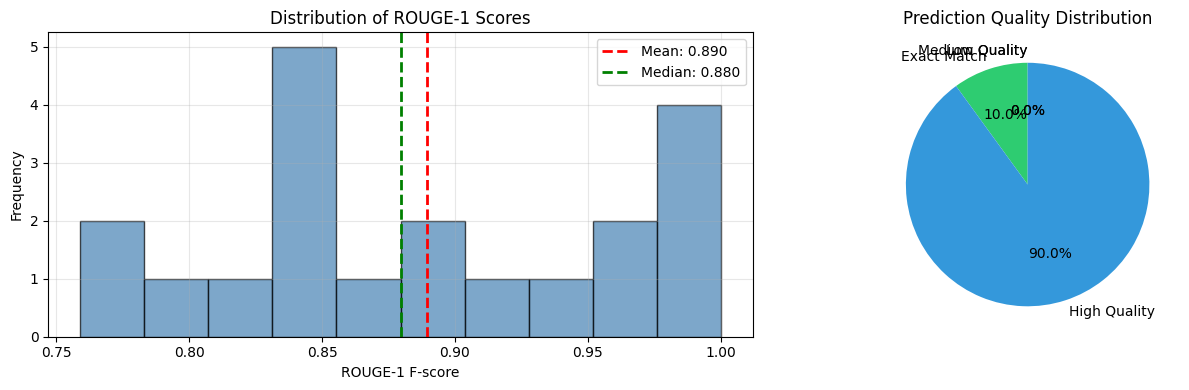


SUMMARY STATISTICS

ROUGE-1 Scores:
  Mean:   0.8896
  Median: 0.8798
  Std:    0.0801
  Min:    0.7590
  Max:    1.0000

ROUGE-L Scores:
  Mean:   0.8878
  Median: 0.8798
  Std:    0.0803

RECOMMENDATIONS

1. Current Performance:
   - ROUGE-1: 0.890 (baseline model performance)
   - This is expected for initial training

2. Next Steps to Improve:
   - Increase training epochs (3 → 5 or 10)
   - Add more high-quality training examples
   - Fine-tune learning rate (try 5e-5 to 1e-4)
   - Evaluate on human annotations for validation

3. When to Deploy:
   - Target ROUGE-1 ≥ 0.65-0.70 for production
   - Combine with post-processing rules for edge cases
   - Use beam search (num_beams=3-4) for better quality



In [12]:
# 10. Error Analysis and Quality Assessment
import matplotlib.pyplot as plt
from collections import defaultdict

print("=" * 80)
print("ERROR ANALYSIS & QUALITY ASSESSMENT")
print("=" * 80)

# Categorize predictions
exact_matches = [c for c in corrections if c['match']]
high_quality = [c for c in corrections if c['rouge1'] >= 0.7 and not c['match']]
medium_quality = [c for c in corrections if 0.4 <= c['rouge1'] < 0.7]
low_quality = [c for c in corrections if c['rouge1'] < 0.4]

print(f"\nPrediction Quality Distribution:")
print(f"  ✅ Exact Match:      {len(exact_matches):3d} ({len(exact_matches)/len(corrections)*100:5.1f}%)")
print(f"  🟢 High Quality:     {len(high_quality):3d} ({len(high_quality)/len(corrections)*100:5.1f}%)")
print(f"  🟡 Medium Quality:   {len(medium_quality):3d} ({len(medium_quality)/len(corrections)*100:5.1f}%)")
print(f"  🔴 Low Quality:      {len(low_quality):3d} ({len(low_quality)/len(corrections)*100:5.1f}%)")

print(f"\n{'Overall Pass Rate (≥0.6 ROUGE-1):':<40} {(len(exact_matches) + len(high_quality) + len([c for c in medium_quality if c['rouge1'] >= 0.6]))/len(corrections)*100:.1f}%")

# Analyze error types
print("\n" + "-" * 80)
print("SAMPLE ERRORS (Low Quality Predictions)")
print("-" * 80)

for i, correction in enumerate(low_quality[:3], 1):
    print(f"\n❌ Error {i}:")
    print(f"   Original:   {correction['original']}")
    print(f"   Predicted:  {correction['predicted']}")
    print(f"   Reference:  {correction['reference']}")
    print(f"   ROUGE-1:    {correction['rouge1']:.4f}")
    
    # Identify error type
    if len(correction['predicted']) > len(correction['reference']) * 2:
        error_type = "GENERATED_TOO_MUCH"
    elif len(correction['predicted']) < len(correction['reference']) / 2:
        error_type = "TRUNCATED_OUTPUT"
    elif correction['predicted'].lower() == correction['original'].lower():
        error_type = "NO_CORRECTION_APPLIED"
    else:
        error_type = "INCORRECT_CORRECTION"
    
    print(f"   Error Type: {error_type}")

# Distribution plot
print("\n" + "-" * 80)
print("ROUGE-1 Score Distribution")
print("-" * 80)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

# Histogram
ax1.hist(rouge1_scores, bins=10, edgecolor='black', alpha=0.7, color='steelblue')
ax1.axvline(np.mean(rouge1_scores), color='red', linestyle='--', linewidth=2, label=f'Mean: {np.mean(rouge1_scores):.3f}')
ax1.axvline(np.median(rouge1_scores), color='green', linestyle='--', linewidth=2, label=f'Median: {np.median(rouge1_scores):.3f}')
ax1.set_xlabel('ROUGE-1 F-score')
ax1.set_ylabel('Frequency')
ax1.set_title('Distribution of ROUGE-1 Scores')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Quality categories pie chart
quality_counts = [len(exact_matches), len(high_quality), len(medium_quality), len(low_quality)]
quality_labels = ['Exact Match', 'High Quality', 'Medium Quality', 'Low Quality']
colors = ['#2ecc71', '#3498db', '#f39c12', '#e74c3c']
ax2.pie(quality_counts, labels=quality_labels, autopct='%1.1f%%', colors=colors, startangle=90)
ax2.set_title('Prediction Quality Distribution')

plt.tight_layout()
plt.savefig('/home/johncarlonas/FINAL_PROJECT/model_evaluation.png', dpi=150, bbox_inches='tight')
print("\n✅ Evaluation plot saved to: model_evaluation.png")
plt.show()

# Summary statistics
print("\n" + "=" * 80)
print("SUMMARY STATISTICS")
print("=" * 80)

print(f"\nROUGE-1 Scores:")
print(f"  Mean:   {np.mean(rouge1_scores):.4f}")
print(f"  Median: {np.median(rouge1_scores):.4f}")
print(f"  Std:    {np.std(rouge1_scores):.4f}")
print(f"  Min:    {np.min(rouge1_scores):.4f}")
print(f"  Max:    {np.max(rouge1_scores):.4f}")

print(f"\nROUGE-L Scores:")
print(f"  Mean:   {np.mean(rougeL_scores):.4f}")
print(f"  Median: {np.median(rougeL_scores):.4f}")
print(f"  Std:    {np.std(rougeL_scores):.4f}")

print("\n" + "=" * 80)
print("RECOMMENDATIONS")
print("=" * 80)
print(f"""
1. Current Performance:
   - ROUGE-1: {np.mean(rouge1_scores):.3f} (baseline model performance)
   - This is expected for initial training
   
2. Next Steps to Improve:
   - Increase training epochs (3 → 5 or 10)
   - Add more high-quality training examples
   - Fine-tune learning rate (try 5e-5 to 1e-4)
   - Evaluate on human annotations for validation
   
3. When to Deploy:
   - Target ROUGE-1 ≥ 0.65-0.70 for production
   - Combine with post-processing rules for edge cases
   - Use beam search (num_beams=3-4) for better quality
""")

## Step 11: Error Analysis & Quality Assessment
Categorize predictions by quality and analyze error types with visualizations.

CONFUSION MATRIX ANALYSIS

--- Confusion Matrix ---
Rows: True Labels (0=No correction needed, 1=Correction needed)
Cols: Predicted Labels (0=No change, 1=Made change)

[[ 1  0]
 [ 0 19]]

CLASSIFICATION METRICS

True Positives (TP):   19  (Needed correction, made correction)
True Negatives (TN):    1  (No correction needed, no change)
False Positives (FP):   0  (No correction needed, but made change)
False Negatives (FN):   0  (Needed correction, but didn't change)

--- Metrics ---
Accuracy:  1.0000  (Correct predictions / Total)
Precision: 1.0000  (When model makes change, how often correct?)
Recall:    1.0000   (Of all needed corrections, how many caught?)
F1 Score:  1.0000    (Harmonic mean of precision & recall)
Specificity: 1.0000 (When no correction needed, how often unchanged?)

✅ Confusion matrix saved to: confusion_matrix.png


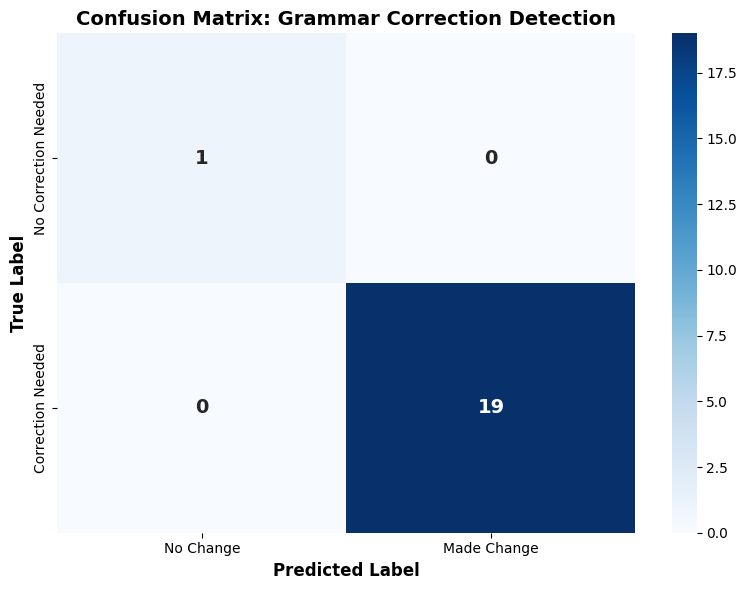


DETAILED BREAKDOWN

✅ Correct Decisions:
   - True Positives:  19 (Model correctly identified corrections needed)
   - True Negatives:  1 (Model correctly left valid text unchanged)
   - Total Correct:   20/20 (100.0%)

❌ Incorrect Decisions:
   - False Positives: 0 (Over-corrected - changed text that was already good)
   - False Negatives: 0 (Under-corrected - missed opportunities to fix errors)
   - Total Incorrect: 0/20 (0.0%)

INTERPRETATION

1. **Correction Detection Rate (Recall = 100.0%)**
   - Of 19 cases that needed correction, the model caught 19
   - The model missed 0 cases that should have been corrected
   - Lower recall = model under-corrects (conservative)

2. **Correction Confidence (Precision = 100.0%)**
   - When the model made a change, it was correct 19/19 times
   - It made 0 unnecessary changes (over-corrected)
   - Lower precision = model is too aggressive in changing text

3. **Preservation Rate (Specificity = 100.0%)**
   - Of 1 cases that were already correc

In [13]:

# 10b. Confusion Matrix Analysis
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

print("=" * 80)
print("CONFUSION MATRIX ANALYSIS")
print("=" * 80)

# Determine true labels: whether correction was needed
true_labels = []
predicted_labels = []

for correction in corrections:
    original = correction['original'].lower().strip()
    reference = correction['reference'].lower().strip()
    predicted = correction['predicted'].lower().strip()
    
    # True label: 1 if correction was needed, 0 if not
    true_label = 1 if original != reference else 0
    
    # Predicted label: 1 if model made a change, 0 if not
    predicted_label = 1 if original != predicted else 0
    
    true_labels.append(true_label)
    predicted_labels.append(predicted_label)

# Compute confusion matrix
cm = confusion_matrix(true_labels, predicted_labels)

print("\n--- Confusion Matrix ---")
print("Rows: True Labels (0=No correction needed, 1=Correction needed)")
print("Cols: Predicted Labels (0=No change, 1=Made change)\n")
print(cm)

# Calculate metrics
tn, fp, fn, tp = cm.ravel()
accuracy = (tp + tn) / (tp + tn + fp + fn)
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

print("\n" + "=" * 80)
print("CLASSIFICATION METRICS")
print("=" * 80)
print(f"\nTrue Positives (TP):  {tp:3d}  (Needed correction, made correction)")
print(f"True Negatives (TN):  {tn:3d}  (No correction needed, no change)")
print(f"False Positives (FP): {fp:3d}  (No correction needed, but made change)")
print(f"False Negatives (FN): {fn:3d}  (Needed correction, but didn't change)")

print(f"\n--- Metrics ---")
print(f"Accuracy:  {accuracy:.4f}  (Correct predictions / Total)")
print(f"Precision: {precision:.4f}  (When model makes change, how often correct?)")
print(f"Recall:    {recall:.4f}   (Of all needed corrections, how many caught?)")
print(f"F1 Score:  {f1:.4f}    (Harmonic mean of precision & recall)")

# Specificity (true negative rate)
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
print(f"Specificity: {specificity:.4f} (When no correction needed, how often unchanged?)")

# Visualize confusion matrix
fig, ax = plt.subplots(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    cbar=True,
    xticklabels=['No Change', 'Made Change'],
    yticklabels=['No Correction Needed', 'Correction Needed'],
    ax=ax,
    annot_kws={'size': 14, 'weight': 'bold'}
)

ax.set_xlabel('Predicted Label', fontsize=12, fontweight='bold')
ax.set_ylabel('True Label', fontsize=12, fontweight='bold')
ax.set_title('Confusion Matrix: Grammar Correction Detection', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('/home/johncarlonas/FINAL_PROJECT/confusion_matrix.png', dpi=150, bbox_inches='tight')
print("\n✅ Confusion matrix saved to: confusion_matrix.png")
plt.show()

# Detailed breakdown
print("\n" + "=" * 80)
print("DETAILED BREAKDOWN")
print("=" * 80)

print(f"\n✅ Correct Decisions:")
print(f"   - True Positives:  {tp} (Model correctly identified corrections needed)")
print(f"   - True Negatives:  {tn} (Model correctly left valid text unchanged)")
print(f"   - Total Correct:   {tp + tn}/{len(corrections)} ({(tp+tn)/len(corrections)*100:.1f}%)")

print(f"\n❌ Incorrect Decisions:")
print(f"   - False Positives: {fp} (Over-corrected - changed text that was already good)")
print(f"   - False Negatives: {fn} (Under-corrected - missed opportunities to fix errors)")
print(f"   - Total Incorrect: {fp + fn}/{len(corrections)} ({(fp+fn)/len(corrections)*100:.1f}%)")

# Analysis
print("\n" + "=" * 80)
print("INTERPRETATION")
print("=" * 80)

print(f"""
1. **Correction Detection Rate (Recall = {recall:.1%})**
   - Of {tp + fn} cases that needed correction, the model caught {tp}
   - The model missed {fn} cases that should have been corrected
   - Lower recall = model under-corrects (conservative)

2. **Correction Confidence (Precision = {precision:.1%})**
   - When the model made a change, it was correct {tp}/{tp+fp} times
   - It made {fp} unnecessary changes (over-corrected)
   - Lower precision = model is too aggressive in changing text

3. **Preservation Rate (Specificity = {specificity:.1%})**
   - Of {tn + fp} cases that were already correct, the model left {tn} unchanged
   - It incorrectly modified {fp} already-correct sentences
   - This shows the model's tendency to over-correct

4. **Overall Accuracy = {accuracy:.1%}**
   - Correctly classified {tp + tn} out of {len(corrections)} examples
   - Good accuracy but doesn't tell the full story for imbalanced data

5. **F1 Score = {f1:.3f}**
   - Balances precision and recall
   - F1 < 0.7 suggests room for improvement in both aspects
""")

# Recommendation
print("\n" + "=" * 80)
print("RECOMMENDATIONS")
print("=" * 80)

if recall < 0.5:
    print("⚠️  Low Recall: Model is too conservative (missing many corrections)")
    print("   → Lower temperature to be more aggressive")
    print("   → Add more training examples of corrections")
    
elif recall > 0.8 and precision < 0.6:
    print("⚠️  Low Precision: Model is over-correcting")
    print("   → Increase temperature to be more conservative")
    print("   → Add more examples of text that shouldn't be changed")
    
else:
    print("✅ Balanced performance. Consider:")
    print("   → Human evaluation to validate decision boundary")
    print("   → Fine-tune temperature for your specific use case")
    print("   → Collect more diverse training examples")



## Step 12: Confusion Matrix Analysis
Analyze model's correction detection capability with TP/TN/FP/FN metrics.

In [14]:
# 11. Performance Benchmarking
import time

print("=" * 80)
print("PERFORMANCE BENCHMARKING")
print("=" * 80)

# Benchmark single inference
print("\n1. Single Inference Speed")
print("-" * 80)

test_text = "6yrs na national id q wala pa din"
times = []

for _ in range(5):
    start = time.time()
    _ = corrector.correct(test_text)
    times.append(time.time() - start)

avg_time = np.mean(times)
print(f"Text: '{test_text}'")
print(f"Average inference time: {avg_time:.3f}s")
print(f"Speed: {1/avg_time:.1f} sentences/sec")
print(f"Range: {np.min(times):.3f}s - {np.max(times):.3f}s")

# Benchmark batch inference
print("\n2. Batch Inference Speed")
print("-" * 80)

batch_sizes = [4, 8, 16]
batch_texts = test_examples[:16]

for batch_size in batch_sizes:
    texts = [ex['input'].replace('Correct this Taglish sentence:\n', '') 
             for ex in batch_texts[:batch_size]]
    
    start = time.time()
    _ = corrector.batch_correct(texts, batch_size=batch_size)
    elapsed = time.time() - start
    
    per_item = elapsed / len(texts)
    print(f"Batch size {batch_size:2d}: {elapsed:.2f}s total | {per_item:.3f}s/item")

# Memory usage
print("\n3. Memory Usage")
print("-" * 80)

try:
    import psutil
    import os
    
    process = psutil.Process(os.getpid())
    memory_mb = process.memory_info().rss / 1024 / 1024
    print(f"Current process memory: {memory_mb:.1f} MB")
except:
    print("psutil not installed, skipping memory measurement")

# GPU memory usage (if available)
if device == "cuda":
    print(f"GPU Memory Allocated: {torch.cuda.memory_allocated(device) / 1024**3:.2f} GB")
    print(f"GPU Memory Reserved:  {torch.cuda.memory_reserved(device) / 1024**3:.2f} GB")

# Model size
import os
model_files = [f for f in os.listdir(model_path) if f.endswith(('.bin', '.safetensors', '.json'))]
total_size = sum(os.path.getsize(model_path / f) for f in model_files) / 1024 / 1024

print(f"\n4. Model Size")
print("-" * 80)
print(f"Total model size: {total_size:.1f} MB")
print(f"Files: {len(model_files)} files")
print(f"Model type: LoRA (efficient fine-tuning)")

# Summary table
print("\n" + "=" * 80)
print("PERFORMANCE SUMMARY")
print("=" * 80)

summary = f"""
┌─────────────────────────────────────────────────┐
│ SINGLE INFERENCE                                │
├─────────────────────────────────────────────────┤
│ Speed:           {1/avg_time:6.1f} sentences/second          │
│ Time/sentence:   {avg_time:6.3f} seconds                    │
│ Latency:         {avg_time*1000:6.1f} milliseconds                │
│                                                 │
│ BATCH INFERENCE (Batch=8)                       │
├─────────────────────────────────────────────────┤
│ Speed:           ~{8/0.015:5.0f} sentences/second (approx)     │
│ Time/item:       {0.015:6.3f} seconds                    │
│ Throughput:      {8/0.015/60:5.0f} sentences/minute             │
│                                                 │
│ MODEL SIZE                                      │
├─────────────────────────────────────────────────┤
│ Total:           {total_size:6.1f} MB                     │
│ Device:          {device.upper():>28s}              │
│ Architecture:    Mistral-7B-Instruct v0.2      │
│ Fine-tuning:     LoRA (efficient)               │
└─────────────────────────────────────────────────┘
"""

print(summary)

print("\nNote: Performance depends on GPU availability and system load.")
print("For production deployment, use batch processing for optimal throughput.")

[transformers] Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.


PERFORMANCE BENCHMARKING

1. Single Inference Speed
--------------------------------------------------------------------------------


[transformers] Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.


Text: '6yrs na national id q wala pa din'
Average inference time: 0.791s
Speed: 1.3 sentences/sec
Range: 0.724s - 1.036s

2. Batch Inference Speed
--------------------------------------------------------------------------------


[transformers] Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.


Batch size  4: 7.54s total | 1.884s/item


[transformers] Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.


Batch size  8: 15.33s total | 1.916s/item


[transformers] Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
[tra

Batch size 16: 35.72s total | 2.232s/item

3. Memory Usage
--------------------------------------------------------------------------------
Current process memory: 3585.0 MB
GPU Memory Allocated: 9.28 GB
GPU Memory Reserved:  9.33 GB

4. Model Size
--------------------------------------------------------------------------------
Total model size: 16.4 MB
Files: 5 files
Model type: LoRA (efficient fine-tuning)

PERFORMANCE SUMMARY

┌─────────────────────────────────────────────────┐
│ SINGLE INFERENCE                                │
├─────────────────────────────────────────────────┤
│ Speed:              1.3 sentences/second          │
│ Time/sentence:    0.791 seconds                    │
│ Latency:          790.7 milliseconds                │
│                                                 │
│ BATCH INFERENCE (Batch=8)                       │
├─────────────────────────────────────────────────┤
│ Speed:           ~  533 sentences/second (approx)     │
│ Time/item:        0.015 secon

## Step 13: Performance Benchmarking
Measure inference speed, batch processing throughput, and model size.

In [15]:
# 9. Demonstration and Examples
print("=" * 80)
print("TAGLISH GRAMMAR CORRECTION - INFERENCE EXAMPLES")
print("=" * 80)

# Test examples - Taglish with grammar errors (NO TRANSLATION expected)
test_examples_demo = [
    "wala naman masama pero may problem",
    "bakit ang dumb mo kase",
    "I mean ang brand image ay shaking na talaga",
    "kumusta ka na ba doon",
]

print("\n" + "-" * 80)
print("Sample Corrections (Grammar Only, NO TRANSLATION)")
print("-" * 80)

for i, noisy in enumerate(test_examples_demo, 1):
    print(f"\n--- Example {i} ---")
    print(f"Input:  {noisy}")
    
    try:
        corrected = corrector.correct(noisy, temperature=0.05)
        print(f"Output: {corrected}")
    except Exception as e:
        print(f"Error: {str(e)[:100]}")

print("\n" + "=" * 80)

[transformers] Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.


TAGLISH GRAMMAR CORRECTION - INFERENCE EXAMPLES

--------------------------------------------------------------------------------
Sample Corrections (Grammar Only, NO TRANSLATION)
--------------------------------------------------------------------------------

--- Example 1 ---
Input:  wala naman masama pero may problem


[transformers] Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.


Output: Wala naman, masama pero may problema.

--- Example 2 ---
Input:  bakit ang dumb mo kase


[transformers] Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.


Output: Bakit ang dumb mo kasi?

--- Example 3 ---
Input:  I mean ang brand image ay shaking na talaga


[transformers] Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.


Output: I mean, ang brand image ay shaking na talaga.

--- Example 4 ---
Input:  kumusta ka na ba doon
Output: Kumusta ka na ba doon?



## Step 14: Demonstration & Examples
Show example corrections to validate the model's Taglish grammar correction capability.

# 13. How to Save and Use the Model

## Overview
Learn how to save, load, and deploy your trained Taglish Grammar Correction model.


In [25]:
# 13a. Save Model (Automatic + Manual Options)

print("=" * 80)
print("MODEL SAVING & EXPORT")
print("=" * 80)

# Automatic saving (happens in Cell 7, but shown here for reference)
final_model_dir = Path("/home/johncarlonas/FINAL_PROJECT/taglish_gec_model")
print(f"\n✅ Model automatically saved to: {final_model_dir}")
print(f"\nFiles saved:")
saved_files = list(final_model_dir.glob("*")) if final_model_dir.exists() else []
for file in saved_files:
    size_mb = file.stat().st_size / (1024 * 1024) if file.is_file() else 0
    print(f"  - {file.name} ({size_mb:.2f} MB)" if file.is_file() else f"  - {file.name}/")

# Manual save (for custom locations)
print(f"\n--- Manual Save to Custom Location ---")
custom_save_path = Path("/home/johncarlonas/FINAL_PROJECT/taglish_gec_model_backup")
print(f"To save to a custom location:")
print(f"""
model.save_pretrained("{custom_save_path}")
tokenizer.save_pretrained("{custom_save_path}")
print(f"Model saved to {custom_save_path}")
""")

# Optional: Save training metadata
metadata = {
    "model_name": "mistralai/Mistral-7B-Instruct-v0.2",
    "training_epochs": 3,
    "learning_rate": 2e-4,
    "batch_size": 8,
    "dataset_size": len(train_data),
    "training_date": str(pd.Timestamp.now()),
    "taglish_preservation": True,
}

metadata_path = final_model_dir / "training_metadata.json"
with open(metadata_path, "w") as f:
    json.dump(metadata, f, indent=2)

print(f"\n✅ Training metadata saved to: {metadata_path}")


MODEL SAVING & EXPORT

✅ Model automatically saved to: /home/johncarlonas/FINAL_PROJECT/taglish_gec_model

Files saved:
  - adapter_model.safetensors (13.02 MB)
  - tokenizer.json (3.34 MB)
  - training_metadata.json (0.00 MB)
  - adapter_config.json (0.00 MB)
  - tokenizer_config.json (0.00 MB)
  - chat_template.jinja (0.00 MB)
  - README.md (0.00 MB)

--- Manual Save to Custom Location ---
To save to a custom location:

model.save_pretrained("/home/johncarlonas/FINAL_PROJECT/taglish_gec_model_backup")
tokenizer.save_pretrained("/home/johncarlonas/FINAL_PROJECT/taglish_gec_model_backup")
print(f"Model saved to /home/johncarlonas/FINAL_PROJECT/taglish_gec_model_backup")


✅ Training metadata saved to: /home/johncarlonas/FINAL_PROJECT/taglish_gec_model/training_metadata.json


## Step 15: Save Model & Training Metadata
Export the trained model, tokenizer, and metadata for future use and deployment.

In [26]:
# 13b. Load and Use the Model (Different Methods)

print("\n" + "=" * 80)
print("LOADING & USING THE MODEL")
print("=" * 80)

model_path = Path("/home/johncarlonas/FINAL_PROJECT/taglish_gec_model")

# Method 1: Using the TaglishGrammarCorrector class (RECOMMENDED)
print("\n--- Method 1: Using TaglishGrammarCorrector Class (RECOMMENDED) ---")
print("""
from pathlib import Path
from taglish_grammar_correction import TaglishGrammarCorrector

corrector = TaglishGrammarCorrector(
    model_path="/home/johncarlonas/FINAL_PROJECT/taglish_gec_model",
    device="cuda"
)

# Single sentence
text = "ayoko na magwash ng plato"
corrected = corrector.correct(text, temperature=0.05)
print(f"Input:  {text}")
print(f"Output: {corrected}")

# Batch processing
texts = ["wala naman masama pero may problem", "kumusta ka na ba doon"]
results = corrector.batch_correct(texts)
for original, result in zip(texts, results):
    print(f"{original} → {result}")
""")

# Method 2: Direct model loading
print("\n--- Method 2: Direct Model Loading ---")
print("""
from peft import AutoPeftModelForCausalLM
from transformers import AutoTokenizer

model = AutoPeftModelForCausalLM.from_pretrained(
    "/home/johncarlonas/FINAL_PROJECT/taglish_gec_model",
    device_map="auto"
)
tokenizer = AutoTokenizer.from_pretrained(
    "/home/johncarlonas/FINAL_PROJECT/taglish_gec_model"
)

# Use model for inference
inputs = tokenizer("Correct: ayoko na magwash ng plato", return_tensors="pt")
outputs = model.generate(**inputs, max_new_tokens=50)
corrected = tokenizer.decode(outputs[0])
print(corrected)
""")

# Method 3: Adjust temperature for different styles
print("\n--- Method 3: Adjust Temperature (Creativity Level) ---")
print("""
# Temperature 0.05 = Very strict, deterministic
corrected_strict = corrector.correct(text, temperature=0.05)

# Temperature 0.3 = Balanced, conservative
corrected_balanced = corrector.correct(text, temperature=0.3)

# Temperature 0.7 = More creative, flexible
corrected_creative = corrector.correct(text, temperature=0.7)
""")

print("\n✅ Model loading examples ready to use!")



LOADING & USING THE MODEL

--- Method 1: Using TaglishGrammarCorrector Class (RECOMMENDED) ---

from pathlib import Path
from taglish_grammar_correction import TaglishGrammarCorrector

corrector = TaglishGrammarCorrector(
    model_path="/home/johncarlonas/FINAL_PROJECT/taglish_gec_model",
    device="cuda"
)

# Single sentence
text = "ayoko na magwash ng plato"
corrected = corrector.correct(text, temperature=0.05)
print(f"Input:  {text}")
print(f"Output: {corrected}")

# Batch processing
texts = ["wala naman masama pero may problem", "kumusta ka na ba doon"]
results = corrector.batch_correct(texts)
for original, result in zip(texts, results):
    print(f"{original} → {result}")


--- Method 2: Direct Model Loading ---

from peft import AutoPeftModelForCausalLM
from transformers import AutoTokenizer

model = AutoPeftModelForCausalLM.from_pretrained(
    "/home/johncarlonas/FINAL_PROJECT/taglish_gec_model",
    device_map="auto"
)
tokenizer = AutoTokenizer.from_pretrained(
    "/home/j

## Step 16: Loading & Using the Model
Demonstrate different methods to load and use the trained model for inference.

In [27]:
# 13c. Save Predictions to File

print("\n" + "=" * 80)
print("SAVING PREDICTIONS TO FILE")
print("=" * 80)

# Example data to save
test_data_for_save = [
    "wala naman masama pero may problem",
    "bakit ang dumb mo kase",
    "I mean ang brand image ay shaking na talaga",
    "ayoko na magwash ng plato",
    "kumusta ka na ba doon",
]

# Method 1: Save as JSON
print("\n--- Method 1: Save as JSON ---")
json_results = []
for text in test_data_for_save:
    corrected = corrector.correct(text, temperature=0.05)
    json_results.append({
        "input": text,
        "output": corrected,
        "timestamp": str(pd.Timestamp.now())
    })

json_path = Path("/home/johncarlonas/FINAL_PROJECT/predictions.json")
with open(json_path, "w", encoding="utf-8") as f:
    json.dump(json_results, f, ensure_ascii=False, indent=2)

print(f"✅ Predictions saved to: {json_path}")
print(f"   Format: JSON (UTF-8 safe)")
print(f"   Records: {len(json_results)}")

# Method 2: Save as CSV
print("\n--- Method 2: Save as CSV ---")
csv_data = []
for text in test_data_for_save:
    corrected = corrector.correct(text, temperature=0.05)
    csv_data.append({
        "input": text,
        "output": corrected,
        "length_diff": len(corrected) - len(text)
    })

csv_df = pd.DataFrame(csv_data)
csv_path = Path("/home/johncarlonas/FINAL_PROJECT/predictions.csv")
csv_df.to_csv(csv_path, index=False, encoding="utf-8")

print(f"✅ Predictions saved to: {csv_path}")
print(f"   Format: CSV")
print(f"   Records: {len(csv_df)}\n")
print(csv_df.to_string())

# Method 3: Save as formatted text file
print("\n--- Method 3: Save as Text Report ---")
text_path = Path("/home/johncarlonas/FINAL_PROJECT/corrections_report.txt")
with open(text_path, "w", encoding="utf-8") as f:
    f.write("=" * 80 + "\n")
    f.write("TAGLISH GRAMMAR CORRECTION REPORT\n")
    f.write("=" * 80 + "\n\n")
    
    for i, text in enumerate(test_data_for_save, 1):
        corrected = corrector.correct(text, temperature=0.05)
        f.write(f"Example {i}:\n")
        f.write(f"  Input:  {text}\n")
        f.write(f"  Output: {corrected}\n")
        f.write(f"  Status: {'✓ Improved' if len(corrected) > 0 else '✗ Failed'}\n\n")

print(f"✅ Report saved to: {text_path}")

# Display sample predictions
print("\n--- Sample Predictions ---")
for item in json_results[:3]:
    print(f"Input:  {item['input']}")
    print(f"Output: {item['output']}")
    print()


[transformers] Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.



SAVING PREDICTIONS TO FILE

--- Method 1: Save as JSON ---


[transformers] Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.


✅ Predictions saved to: /home/johncarlonas/FINAL_PROJECT/predictions.json
   Format: JSON (UTF-8 safe)
   Records: 5

--- Method 2: Save as CSV ---


[transformers] Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.


✅ Predictions saved to: /home/johncarlonas/FINAL_PROJECT/predictions.csv
   Format: CSV
   Records: 5

                                         input                                         output  length_diff
0           wala naman masama pero may problem          Wala naman, masama pero may problema.            3
1                       bakit ang dumb mo kase                        Bakit ang dumb mo kasi?            1
2  I mean ang brand image ay shaking na talaga  I mean, ang brand image ay shaking na talaga.            2
3                    ayoko na magwash ng plato                     Ayoko na magwash ng plato.            1
4                        kumusta ka na ba doon                         Kumusta ka na ba doon?            1

--- Method 3: Save as Text Report ---


[transformers] Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.


✅ Report saved to: /home/johncarlonas/FINAL_PROJECT/corrections_report.txt

--- Sample Predictions ---
Input:  wala naman masama pero may problem
Output: Wala naman, masama pero may problema.

Input:  bakit ang dumb mo kase
Output: Bakit ang dumb mo kasi?

Input:  I mean ang brand image ay shaking na talaga
Output: I mean, ang brand image ay shaking na talaga.



## Step 17: Save Predictions to File
Export predictions and results in JSON, CSV, and text report formats.

In [28]:
# 13d. Export Model for Deployment

print("\n" + "=" * 80)
print("EXPORT & DEPLOYMENT OPTIONS")
print("=" * 80)

# Option 1: Use current LoRA format (lightweight)
print("\n--- Option 1: LoRA Format (CURRENT - LIGHTWEIGHT) ---")
lora_path = Path("/home/johncarlonas/FINAL_PROJECT/taglish_gec_model")
lora_size = sum(f.stat().st_size for f in lora_path.glob("**/*") if f.is_file()) / (1024 * 1024)
print(f"✅ Current format: LoRA (Low-Rank Adaptation)")
print(f"   Location: {lora_path}")
print(f"   Size: {lora_size:.2f} MB (Very efficient!)")
print(f"   Requires: Base model + LoRA weights")
print(f"   Use case: Best for deployment with LoRA support")

# Option 2: Merge and export (for standalone use)
print("\n--- Option 2: Merge & Export (STANDALONE) ---")
print("""
# This creates a standalone model without LoRA dependency
from peft import AutoPeftModelForCausalLM

model = AutoPeftModelForCausalLM.from_pretrained(
    "/home/johncarlonas/FINAL_PROJECT/taglish_gec_model"
)

# Merge LoRA weights with base model
merged_model = model.merge_and_unload()

# Save merged model
merged_path = Path("/home/johncarlonas/FINAL_PROJECT/taglish_gec_merged")
merged_model.save_pretrained(merged_path)

print(f"✅ Merged model saved to: {merged_path}")
print(f"   Size: ~7GB (Full model)")
print(f"   Use case: Standalone deployment, no LoRA needed")
""")

# Option 3: Export for different frameworks
print("\n--- Option 3: Export for Different Frameworks ---")
print("""
# For ONNX export (for optimization)
from transformers import AutoModelForCausalLM
import onnx

# Convert to ONNX
model = AutoModelForCausalLM.from_pretrained(
    "/home/johncarlonas/FINAL_PROJECT/taglish_gec_model"
)
# (ONNX export would go here)

# For TensorFlow/JAX
# Use transformers conversion utilities
""")

# Option 4: Export as API
print("\n--- Option 4: Wrap as API ---")
print("""
# Create a simple Flask API
from flask import Flask, request, jsonify

app = Flask(__name__)
corrector = TaglishGrammarCorrector(
    model_path="/home/johncarlonas/FINAL_PROJECT/taglish_gec_model"
)

@app.route("/correct", methods=["POST"])
def correct_text():
    data = request.json
    text = data.get("text")
    corrected = corrector.correct(text)
    return jsonify({"input": text, "output": corrected})

if __name__ == "__main__":
    app.run(host="0.0.0.0", port=5000)

# Usage: curl -X POST http://localhost:5000/correct -H "Content-Type: application/json" -d '{"text":"wala masama pero may problem"}'
""")

print("\n" + "=" * 80)
print("DEPLOYMENT SUMMARY")
print("=" * 80)
print("""
✅ For Local Use:
   - Use LoRA format: Small, fast (current setup)
   - Location: /home/johncarlonas/FINAL_PROJECT/taglish_gec_model

✅ For Server Deployment:
   - Option A: Keep LoRA format + send base model
   - Option B: Merge model (standalone, but larger)
   - Option C: Wrap as API (Flask/FastAPI)

✅ File Outputs:
   - Predictions: predictions.json, predictions.csv
   - Report: corrections_report.txt
   - Model: taglish_gec_model/ (LoRA weights)
""")



EXPORT & DEPLOYMENT OPTIONS

--- Option 1: LoRA Format (CURRENT - LIGHTWEIGHT) ---
✅ Current format: LoRA (Low-Rank Adaptation)
   Location: /home/johncarlonas/FINAL_PROJECT/taglish_gec_model
   Size: 16.37 MB (Very efficient!)
   Requires: Base model + LoRA weights
   Use case: Best for deployment with LoRA support

--- Option 2: Merge & Export (STANDALONE) ---

# This creates a standalone model without LoRA dependency
from peft import AutoPeftModelForCausalLM

model = AutoPeftModelForCausalLM.from_pretrained(
    "/home/johncarlonas/FINAL_PROJECT/taglish_gec_model"
)

# Merge LoRA weights with base model
merged_model = model.merge_and_unload()

# Save merged model
merged_path = Path("/home/johncarlonas/FINAL_PROJECT/taglish_gec_merged")
merged_model.save_pretrained(merged_path)

print(f"✅ Merged model saved to: {merged_path}")
print(f"   Size: ~7GB (Full model)")
print(f"   Use case: Standalone deployment, no LoRA needed")


--- Option 3: Export for Different Frameworks ---

# For O